#***Importing Libraries***



In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score, auc
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import GridSearchCV
import joblib
from sklearn.linear_model import LogisticRegression
import shap


#***Importing and Merging data***

In [ ]:
account_activity=pd.read_csv('account_activity.csv')
amount_data=pd.read_csv('amount_data.csv')
anomaly_scores=pd.read_csv('anomaly_scores.csv')
customer_data=pd.read_csv('customer_data.csv')
fraud_indicators=pd.read_csv('fraud_indicators.csv')
merchant_data=pd.read_csv('merchant_data.csv')
suspicious_activity=pd.read_csv('suspicious_activity.csv')
transaction_category_labels=pd.read_csv('transaction_category_labels.csv')
transaction_metadata=pd.read_csv('transaction_metadata.csv')
transaction_records=pd.read_csv('transaction_records.csv')

In [ ]:
# using merge function to merge the datasets in one dataframe using left
df= amount_data.merge(anomaly_scores, on='TransactionID', how='left') \
                             .merge(transaction_category_labels, on='TransactionID', how='left') \
                             .merge(transaction_metadata, on='TransactionID', how='left') \
                             .merge(fraud_indicators, on='TransactionID', how='left')\
                             .merge(transaction_records, on='TransactionID' , how='left')\
                             .merge(customer_data, on='CustomerID', how='left')\
                             .merge(merchant_data, on='MerchantID', how='left')\
                             .merge(account_activity, on='CustomerID', how='left')\
                             .merge(suspicious_activity, on='CustomerID', how='left')

#***Data Cleaning and Exploration***

In [ ]:
df.head()

,TransactionID,TransactionAmount,AnomalyScore,Category,Timestamp,MerchantID,FraudIndicator,Amount,CustomerID,Name,Age,Address,MerchantName,Location,AccountBalance,LastLogin,SuspiciousFlag
0,1,79.413607,0.686699,Other,2022-01-01 00:00:00,2701,0,55.530334,1952,Customer 1952,50,Address 1952,Merchant 2701,Location 2701,2869.689912,2024-08-09,0
1,2,12.053087,0.081749,Online,2022-01-01 01:00:00,2070,0,12.881180,1027,Customer 1027,46,Address 1027,Merchant 2070,Location 2070,9527.947107,2022-01-27,0
2,3,33.310357,0.023857,Travel,2022-01-01 02:00:00,2238,0,50.176322,1955,Customer 1955,34,Address 1955,Merchant 2238,Location 2238,9288.355525,2024-08-12,0
3,4,46.121117,0.876994,Travel,2022-01-01 03:00:00,2879,0,41.634001,1796,Customer 1796,33,Address 1796,Merchant 2879,Location 2879,5588.049942,2024-03-06,0
4,5,54.051618,0.034059,Other,2022-01-01 04:00:00,2966,0,78.122853,1946,Customer 1946,18,Address 1946,Merchant 2966,Location 2966,7324.785332,2024-08-03,0


In [ ]:
# checking if their null values
df.isna().sum()

,0
TransactionID,0
TransactionAmount,0
AnomalyScore,0
Category,0
Timestamp,0
MerchantID,0
FraudIndicator,0
Amount,0
CustomerID,0
Name,0


In [ ]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# get a full overview about the columns and their datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      1000 non-null   int64  
 1   TransactionAmount  1000 non-null   float64
 2   AnomalyScore       1000 non-null   float64
 3   Category           1000 non-null   object 
 4   Timestamp          1000 non-null   object 
 5   MerchantID         1000 non-null   int64  
 6   FraudIndicator     1000 non-null   int64  
 7   Amount             1000 non-null   float64
 8   CustomerID         1000 non-null   int64  
 9   Name               1000 non-null   object 
 10  Age                1000 non-null   int64  
 11  Address            1000 non-null   object 
 12  MerchantName       1000 non-null   object 
 13  Location           1000 non-null   object 
 14  AccountBalance     1000 non-null   float64
 15  LastLogin          1000 non-null   object 
 16  SuspiciousFlag     1000 n

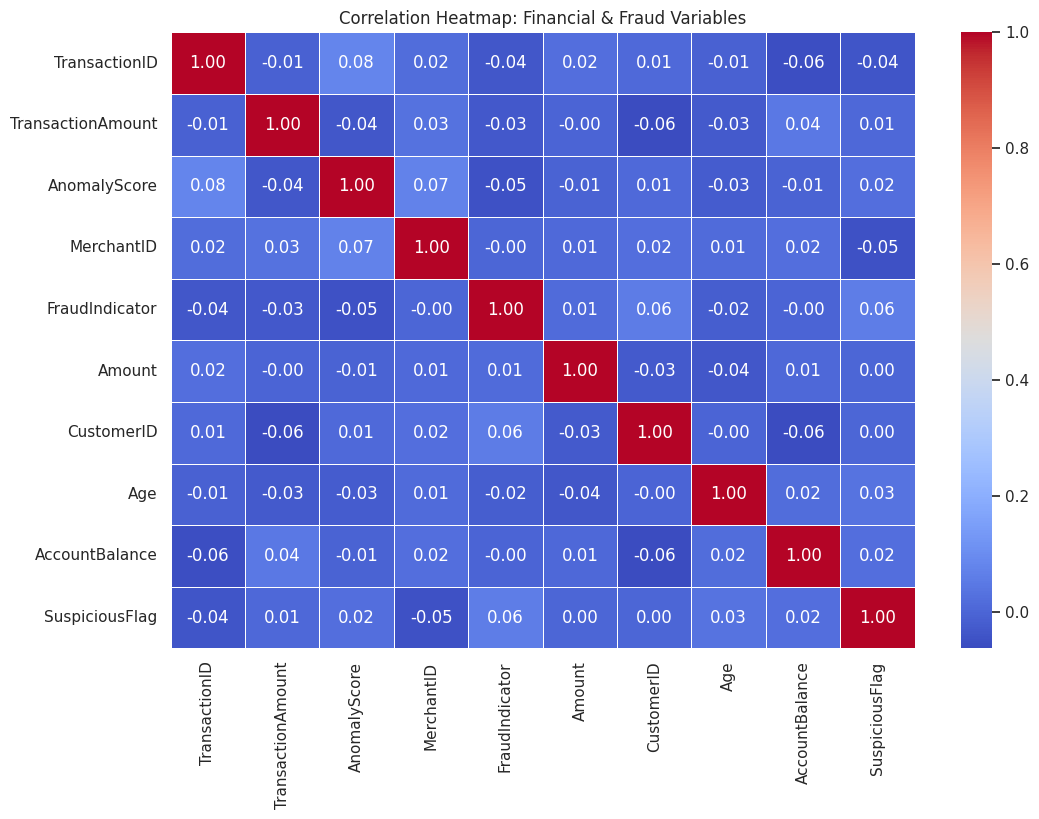

In [ ]:
# numerical dataframe that contains floats and integers
numerical_cols = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numerical_cols.corr()
plt.figure(figsize=(12, 8))

#set the shape details of the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Financial & Fraud Variables')
plt.show()

In [ ]:
print(f"Fraud count after fixed merge: {df['FraudIndicator'].sum()}")

Fraud count after fixed merge: 45


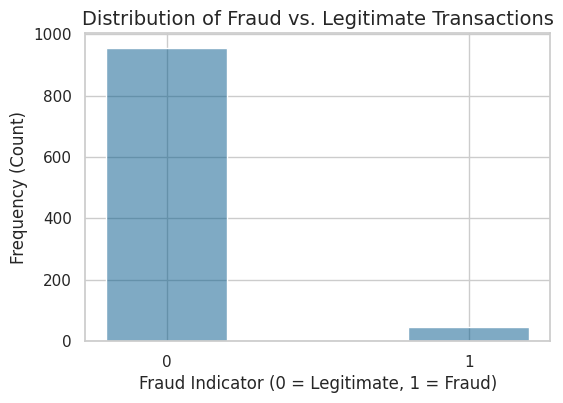

In [ ]:
# Set the visualization style
plt.figure(figsize=(6, 4))

# 1. Convert FraudIndicator to string so it treats 0 and 1 as categories
sns.histplot(data=df,
             x=df['FraudIndicator'].astype(str),
             hue=df['FraudIndicator'].astype(str),
             bins=2,                                   # bins=2 to ensure exactly two bars
             shrink=0.4,                               # shrink=0.4 set the distance between bars
             palette={'0': '#00578a', '1': '#00578a'}) # Changed to a single blue shade

plt.title('Distribution of Fraud vs. Legitimate Transactions', fontsize=14)
plt.xlabel('Fraud Indicator (0 = Legitimate, 1 = Fraud)', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)

# Remove the legend
plt.gca().get_legend().remove()

plt.show()

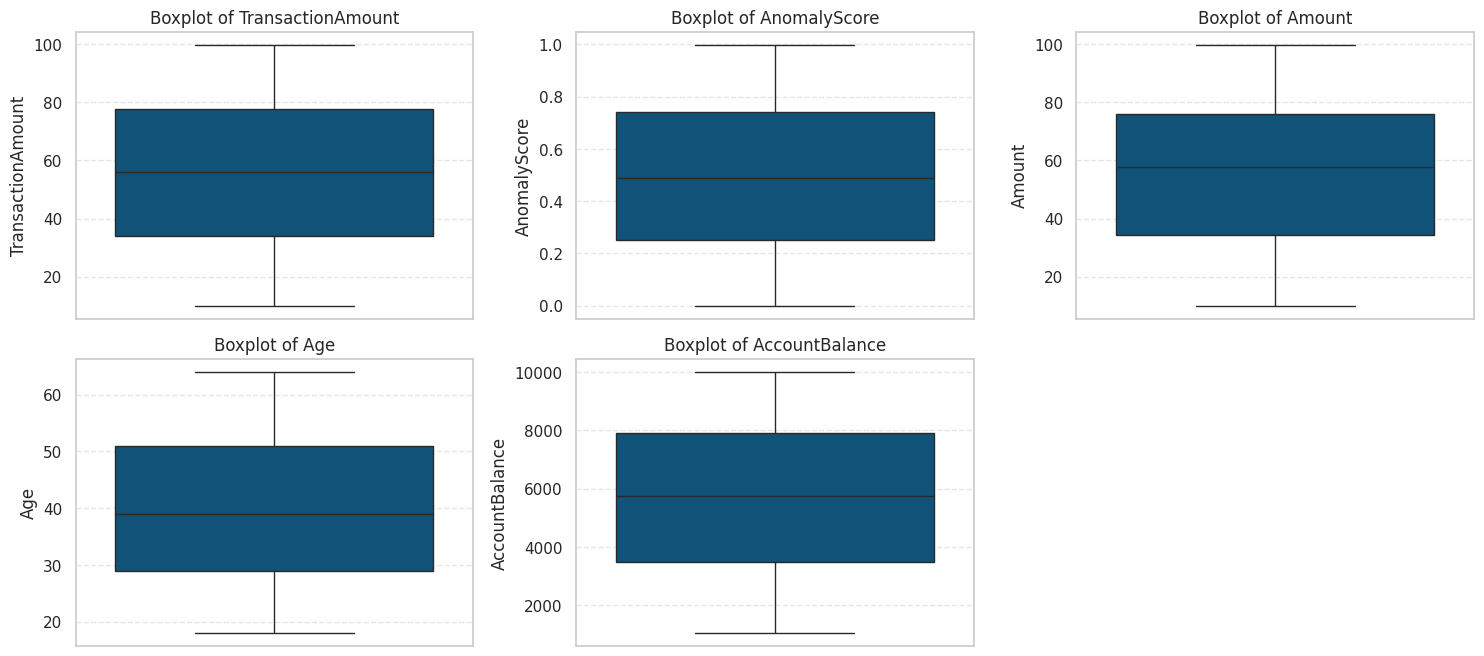

In [ ]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Exclude IDs and target variables that aren't suitable for statistical boxplots
cols_to_plot = [col for col in numerical_cols if col not in ['TransactionID', 'CustomerID', 'MerchantID', 'FraudIndicator', 'SuspiciousFlag']]
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='#00578a')
    plt.title(f'Boxplot of {col}')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

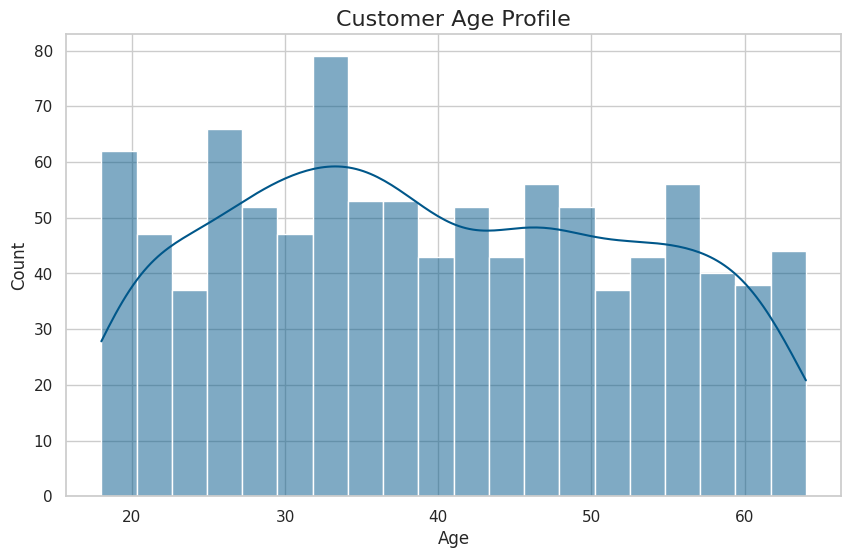

In [ ]:
# Age Distribution according to the fraud indicator
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True, color='#00578a', line_kws={'color': 'red'})

plt.title('Customer Age Profile', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

#***Adding new features***

##***Amount_Diff***
## ***Transaction hour***
##***login day number***
##***TransactionFrequency***
##***Amount_to_Avg_Ratio***



In [ ]:
df['Amount_Diff'] = df['TransactionAmount'] - df['Amount']


In [ ]:
df["Timestamp"]=pd.to_datetime(df["Timestamp"])
df["LastLogin"]=pd.to_datetime(df["LastLogin"])

In [ ]:
df["TransactionFrequency"] = df.groupby('CustomerID')['TransactionID'].transform('count')

In [ ]:
df["transactin_hour"]=df["Timestamp"].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['transactin_hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['transactin_hour'] / 24)
df['Login_Weekday'] = df['LastLogin'].dt.day_name()  # e.g., 'Monday'
df['Login_DayNumber'] = df['LastLogin'].dt.weekday   # e.g., 0 for Monday, 6 for Sunday
df['day_sin'] = np.sin(2 * np.pi * df['Login_DayNumber'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['Login_DayNumber'] / 7)

In [ ]:
# Behavioral Deviation: Current Spend / Average Spend
df['Amount_to_Avg_Ratio'] = df['Amount'] / df.groupby('CustomerID')['Amount'].transform('mean')

In [ ]:
df

,TransactionID,TransactionAmount,AnomalyScore,Category,Timestamp,MerchantID,FraudIndicator,Amount,CustomerID,Name,...,Amount_Diff,TransactionFrequency,transactin_hour,hour_sin,hour_cos,Login_Weekday,Login_DayNumber,day_sin,day_cos,Amount_to_Avg_Ratio
0,1,79.413607,0.686699,Other,2022-01-01 00:00:00,2701,0,55.530334,1952,Customer 1952,...,23.883273,2,0,0.000000e+00,1.000000,Friday,4,-0.433884,-0.900969,1.016907
1,2,12.053087,0.081749,Online,2022-01-01 01:00:00,2070,0,12.881180,1027,Customer 1027,...,-0.828093,1,1,2.588190e-01,0.965926,Thursday,3,0.433884,-0.900969,1.000000
2,3,33.310357,0.023857,Travel,2022-01-01 02:00:00,2238,0,50.176322,1955,Customer 1955,...,-16.865964,2,2,5.000000e-01,0.866025,Monday,0,0.000000,1.000000,0.972716
3,4,46.121117,0.876994,Travel,2022-01-01 03:00:00,2879,0,41.634001,1796,Customer 1796,...,4.487116,4,3,7.071068e-01,0.707107,Wednesday,2,0.974928,-0.222521,0.835199
4,5,54.051618,0.034059,Other,2022-01-01 04:00:00,2966,0,78.122853,1946,Customer 1946,...,-24.071235,1,4,8.660254e-01,0.500000,Saturday,5,-0.974928,-0.222521,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,89.457059,0.266778,Food,2022-02-11 11:00:00,2150,0,19.876750,1411,Customer 1411,...,69.580309,1,11,2.588190e-01,-0.965926,Wednesday,2,0.974928,-0.222521,1.000000
996,997,47.958030,0.512483,Retail,2022-02-11 12:00:00,2888,0,96.299792,1566,Customer 1566,...,-48.341762,1,12,1.224647e-16,-1.000000,Thursday,3,0.433884,-0.900969,1.000000
997,998,64.210046,0.367740,Food,2022-02-11 13:00:00,2037,0,75.164459,1654,Customer 1654,...,-10.954413,1,13,-2.588190e-01,-0.965926,Monday,0,0.000000,1.000000,1.000000
998,999,64.684167,0.960364,Travel,2022-02-11 14:00:00,2629,0,93.633040,1928,Customer 1928,...,-28.948873,2,14,-5.000000e-01,-0.866025,Tuesday,1,0.781831,0.623490,1.556427


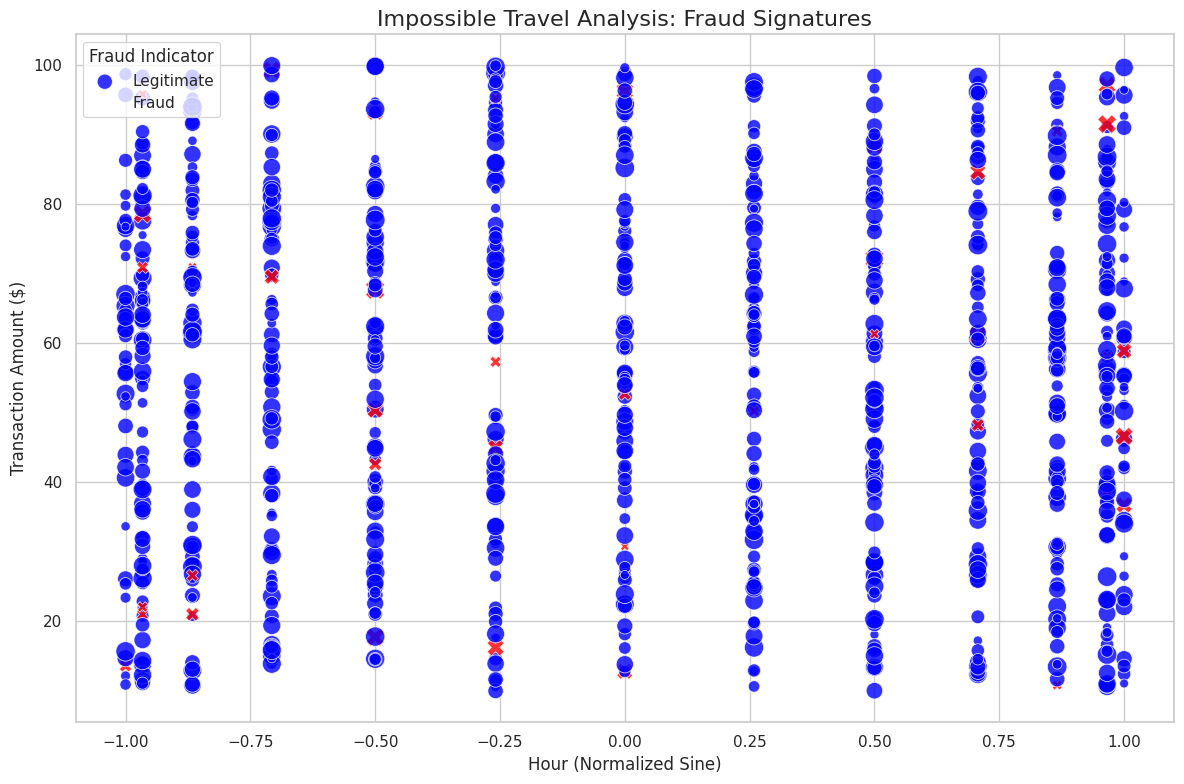

In [ ]:
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Define custom markers and colors
marker_map = {0: "o", 1: "X"}      # 0 (Legitimate) = 'o' (circle)
color_map = {0: "blue", 1: "red"}  # 1 (Fraud) = 'X' (bold x)

# Create the Scatterplot
sns.scatterplot(
    data=df,
    x='hour_sin',
    y='Amount',
    hue='FraudIndicator',          # Controls the color (Blue/Red)
    style='FraudIndicator',        # Controls the shape (Circle/X)
    size='AnomalyScore',           # Size still reflects the Anomaly Score
    sizes=(40, 200),               # Increased size for better visibility
    markers=marker_map,
    palette=color_map,
    alpha=0.8
)

# Formatting
plt.title('Impossible Travel Analysis: Fraud Signatures', fontsize=16)
plt.xlabel('Hour (Normalized Sine)', fontsize=12)
plt.ylabel('Transaction Amount ($)', fontsize=12)
plt.legend(title='Fraud Indicator', loc='upper left', labels=['Legitimate','Fraud'])

plt.tight_layout()
plt.show()

#***Encoding***

In [ ]:
# Group all categories that are NOT 'Online' into a single 'Other' bucket
# This simplifies the data by focusing only on the distinction between Online vs. everything elsedf['Category'] = df['Category'].where(df['Category'] == 'Online', 'Other')

df['Category'] = df['Category'].where(df['Category'] == 'Online', 'Other')
category_dummies = pd.get_dummies(df['Category'], prefix='Category', dtype=int)
df = pd.concat([df, category_dummies], axis=1)
df = df.drop('Category', axis=1)

print("Columns after encoding (Only Online and Other):")
print(df.filter(like='Category').head())

Columns after encoding (Only Online and Other):
   Category_Online  Category_Other
0                0               1
1                1               0
2                0               1
3                0               1
4                0               1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   TransactionID         1000 non-null   int64         
 1   TransactionAmount     1000 non-null   float64       
 2   AnomalyScore          1000 non-null   float64       
 3   Timestamp             1000 non-null   datetime64[ns]
 4   MerchantID            1000 non-null   int64         
 5   FraudIndicator        1000 non-null   int64         
 6   Amount                1000 non-null   float64       
 7   CustomerID            1000 non-null   int64         
 8   Name                  1000 non-null   object        
 9   Age                   1000 non-null   int64         
 10  Address               1000 non-null   object        
 11  MerchantName          1000 non-null   object        
 12  Location              1000 non-null   object        
 13  AccountBalance     

#***Dropping columns***

In [ ]:
#dropping unnecessary columns to reduce the amount of features for the model
df.drop("Name",axis=1,inplace=True)
df.drop("Address",axis=1,inplace=True)
df.drop("TransactionID",axis=1,inplace=True)
df.drop("CustomerID",axis=1,inplace=True)
df.drop("MerchantID",axis=1,inplace=True)
df.drop("MerchantName", axis=1, inplace=True)
df.drop("Timestamp", axis=1, inplace=True)
df.drop("LastLogin", axis=1, inplace=True)
df.drop("Location", axis=1, inplace=True)
df.drop("Login_Weekday", axis=1, inplace=True)
df.drop("transactin_hour", axis=1, inplace=True)
df.drop('Login_DayNumber', axis=1, inplace=True)
df.drop("Amount",axis=1,inplace=True)

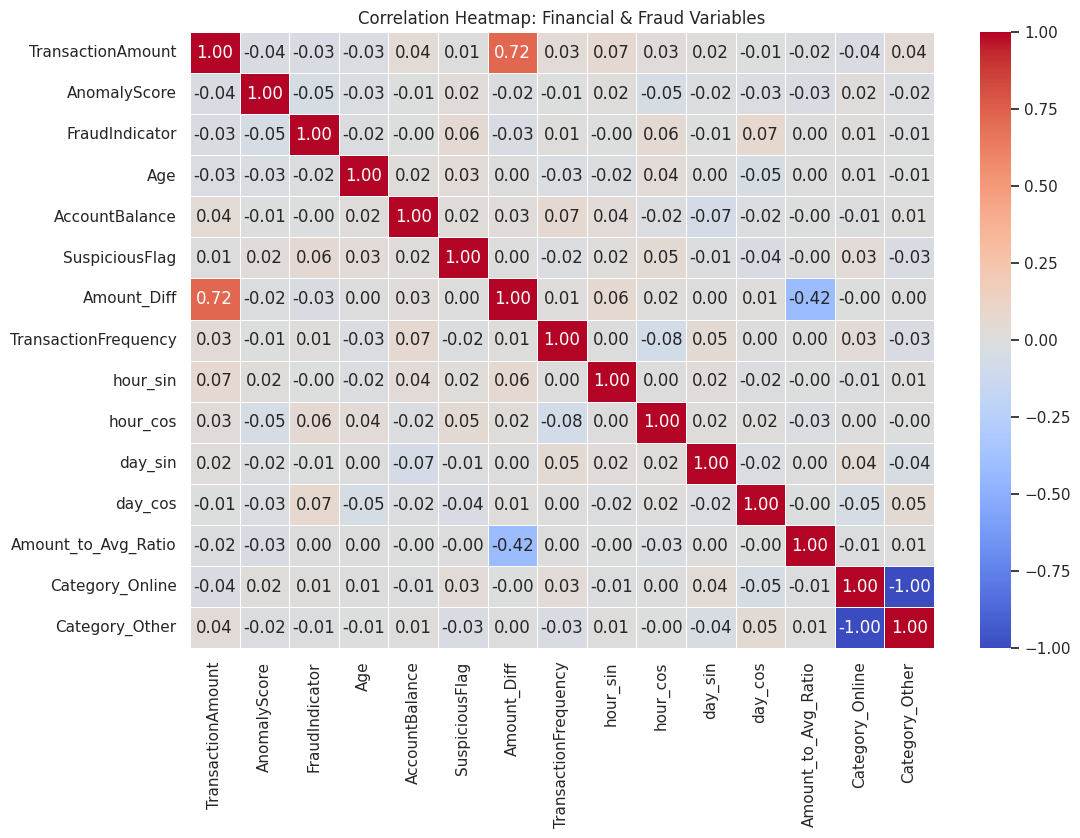

In [ ]:
numerical_cols = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numerical_cols.corr()
plt.figure(figsize=(12, 8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Financial & Fraud Variables')
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionAmount     1000 non-null   float64
 1   AnomalyScore          1000 non-null   float64
 2   FraudIndicator        1000 non-null   int64  
 3   Age                   1000 non-null   int64  
 4   AccountBalance        1000 non-null   float64
 5   SuspiciousFlag        1000 non-null   int64  
 6   Amount_Diff           1000 non-null   float64
 7   TransactionFrequency  1000 non-null   int64  
 8   hour_sin              1000 non-null   float64
 9   hour_cos              1000 non-null   float64
 10  day_sin               1000 non-null   float64
 11  day_cos               1000 non-null   float64
 12  Amount_to_Avg_Ratio   1000 non-null   float64
 13  Category_Online       1000 non-null   int64  
 14  Category_Other        1000 non-null   int64  
dtypes: float64(9), int64(6

In [ ]:
df.head()

,TransactionAmount,AnomalyScore,FraudIndicator,Age,AccountBalance,SuspiciousFlag,Amount_Diff,TransactionFrequency,hour_sin,hour_cos,day_sin,day_cos,Amount_to_Avg_Ratio,Category_Online,Category_Other
0,79.413607,0.686699,0,50,2869.689912,0,23.883273,2,0.000000,1.000000,-0.433884,-0.900969,1.016907,0,1
1,12.053087,0.081749,0,46,9527.947107,0,-0.828093,1,0.258819,0.965926,0.433884,-0.900969,1.000000,1,0
2,33.310357,0.023857,0,34,9288.355525,0,-16.865964,2,0.500000,0.866025,0.000000,1.000000,0.972716,0,1
3,46.121117,0.876994,0,33,5588.049942,0,4.487116,4,0.707107,0.707107,0.974928,-0.222521,0.835199,0,1
4,54.051618,0.034059,0,18,7324.785332,0,-24.071235,1,0.866025,0.500000,-0.974928,-0.222521,1.000000,0,1




#***Split data for training and testing***

In [ ]:
# We keep all columns except the one we want to predict
X = df.drop(columns=['FraudIndicator'])
y = df['FraudIndicator']

# test_size=0.2: 80% of data goes to training, 20% to testing
# random_state=42: Ensures the split is reproducible (you get the same results every time)
# stratify=y: Maintains the same proportion of Fraud vs. Non-Fraud in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
scaler = StandardScaler()
# Scale columns with varying ranges
numerical_cols = [
    'TransactionAmount', 'Age', 'AccountBalance', 'AnomalyScore',
    'Amount_to_Avg_Ratio', 'TransactionFrequency',
    'hour_sin', 'hour_cos', 'day_sin','day_cos',
]
# Fit the scaler to the training data and transform it
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# Transform the test data using the parameters learned from the training data
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

#***SMOTE***

In [ ]:
# Apply SMOTE to the training data only this generates synthetic examples for fraud class until it matches the majority infraud class.
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Before SMOTE - Fraud count: {sum(y_train == 1)}")
print(f"After SMOTE - Fraud count: {sum(y_train_res == 1)}")

Before SMOTE - Fraud count: 36
After SMOTE - Fraud count: 764


# **Random Forest Model**

In [ ]:
# n_estimators=500: Use 500 decision trees.
# max_depth=10: Limit tree depth to prevent the model from over-fitting to the training noise.
# class_weight='balanced': Adjusts weights.
# random_state=100: Ensures consistent results across different runs
rf_model = RandomForestClassifier(n_estimators=500, max_depth=10, class_weight='balanced', random_state=100)
rf_model.fit(X_train_res, y_train_res)

# Instead of a simple 0 or 1, this gives a percentage (e.g., 0.85 chance of fraud)
y_probs = rf_model.predict_proba(X_test)[:, 1]
# Apply a custom threshold of 0.20 to make model more senstive for the fraud.
y_pred_new = (y_probs >= 0.20).astype(int)

In [ ]:
# display the performance metrics
print("Classification Report (Threshold 0.20)")
print(classification_report(y_test, y_pred_new))

Classification Report (Threshold 0.20)
              precision    recall  f1-score   support

           0       0.99      0.70      0.82       191
           1       0.12      0.89      0.22         9

    accuracy                           0.71       200
   macro avg       0.56      0.80      0.52       200
weighted avg       0.95      0.71      0.79       200



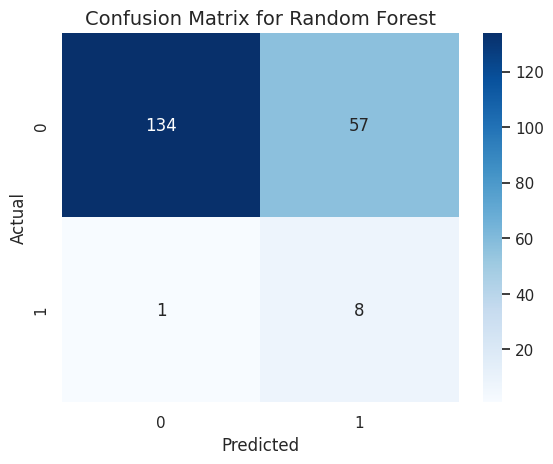

In [ ]:
plt.title('Confusion Matrix for Random Forest', fontsize=14)
sns.heatmap(confusion_matrix(y_test, y_pred_new), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#***Top 10 Important Features***

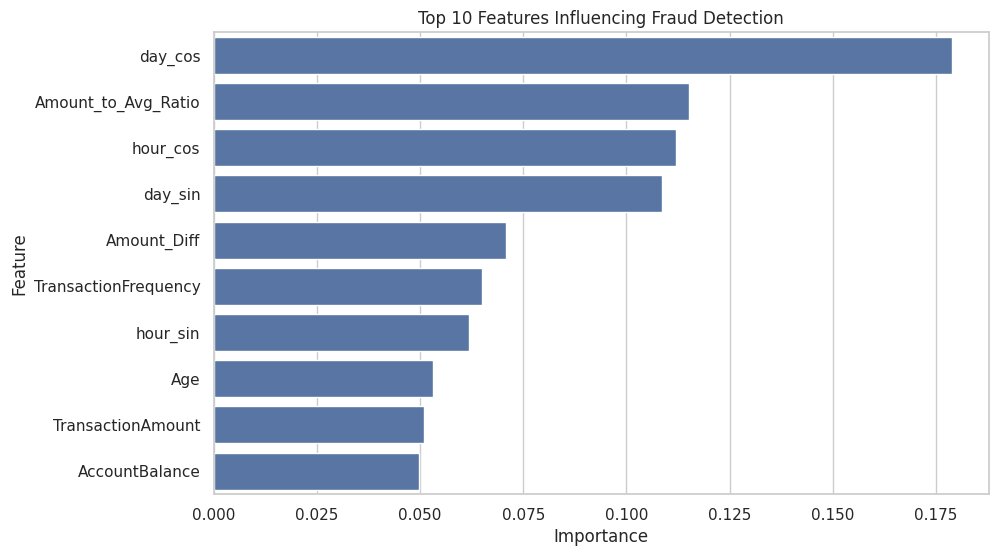

In [ ]:
# display a bar chart of the most important features affect the model
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Features Influencing Fraud Detection')
plt.show()

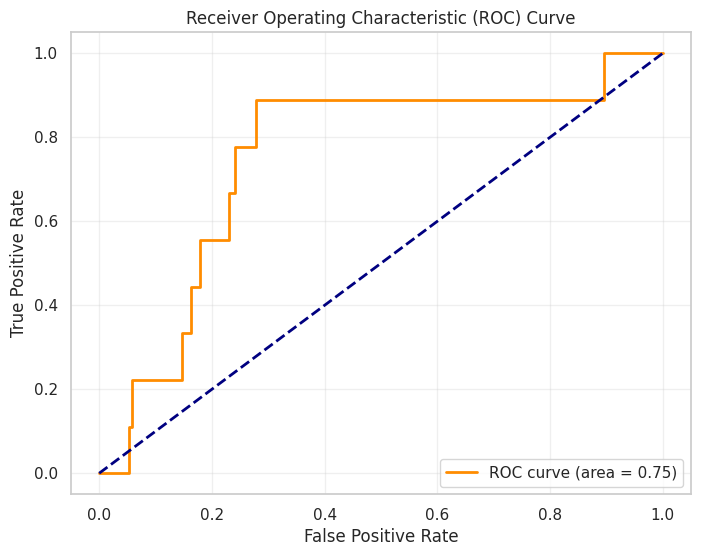

In [ ]:
# Calculate the trade-offs: How many real frauds we catch vs. how many false alarms we trigger
y_probs = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_value = roc_auc_score(y_test, y_probs)          # Calculate the "Grade" of the model (AUC)

# Plot model's performance line
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
y_probs = rf_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_probs)

print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.7510


# **LOGISTIC REGRESSION**





In [ ]:
# max_iter=1000: Gives the model plenty of "tries" to find the best mathematical fit.
# solver='liblinear': An engine that works particularly well for smaller datasets.
lr = LogisticRegression(max_iter=1000, solver='liblinear')
lr.fit(X_train_res, y_train_res)

# display the performance metrics
y_pred = lr.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      0.81      0.88       191
           1       0.05      0.22      0.09         9

    accuracy                           0.79       200
   macro avg       0.50      0.52      0.48       200
weighted avg       0.92      0.79      0.84       200



#***Hyperparameter Tuning using GridSearchCV***

In [ ]:
# Using GridSearchCV to find the best settings for our model to enhance the performance.
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=500, random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=7,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_res, y_train_res)
best_lr = grid_search.best_estimator_
y_pred_grid = best_lr.predict(X_test)

print(f"\nBest Hyperparameters: {grid_search.best_params_}")
print("\n" + "="*30)
print("CLASSIFICATION REPORT (Optimized)")
print("="*30)
print(classification_report(y_test, y_pred_grid))

Fitting 7 folds for each of 10 candidates, totalling 70 fits

Best Hyperparameters: {'C': 0.01, 'solver': 'lbfgs'}

CLASSIFICATION REPORT (Optimized)
              precision    recall  f1-score   support

           0       0.97      0.66      0.79       191
           1       0.07      0.56      0.13         9

    accuracy                           0.66       200
   macro avg       0.52      0.61      0.46       200
weighted avg       0.93      0.66      0.76       200



# **Visualizing the Confusion Matrix**

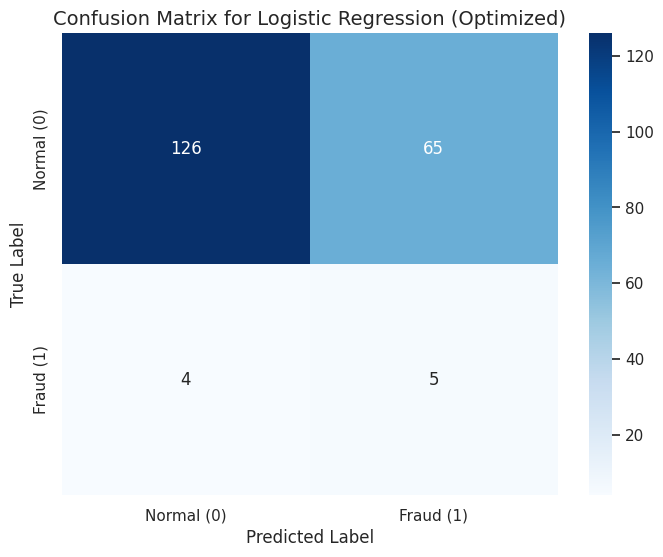

In [ ]:
cm = confusion_matrix(y_test, y_pred_grid)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Fraud (1)'],
            yticklabels=['Normal (0)', 'Fraud (1)'])

plt.title('Confusion Matrix for Logistic Regression (Optimized)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# **Plotting the ROC Curve**

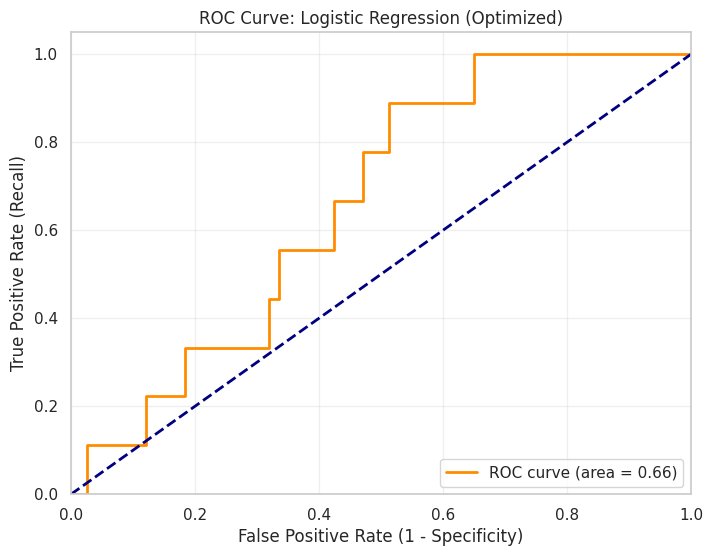

In [ ]:
# Calculate the trade-offs: How many real frauds we catch vs. how many false alarms we trigger
y_probs_grid = best_lr.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_grid)
auc_score = roc_auc_score(y_test, y_probs_grid)      # Calculate the "Grade" of the model (AUC)

# Plot model's performance line
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve: Logistic Regression (Optimized)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

#**XGBoost Model**

In [ ]:
# Train the model
model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=2, use_label_encoder=False,
eval_metric='logloss',random_state=0)
model.fit(X_train_res, y_train_res)
y_pred = model.predict(X_test)

# Evaluate Performance
print("XGBoost Model Performance")
print(classification_report(y_test, y_pred))


XGBoost Model Performance
              precision    recall  f1-score   support

           0       0.99      0.71      0.83       191
           1       0.11      0.78      0.20         9

    accuracy                           0.71       200
   macro avg       0.55      0.74      0.51       200
weighted avg       0.95      0.71      0.80       200



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:26:57] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


#***XGBoost Confusion Matrix***

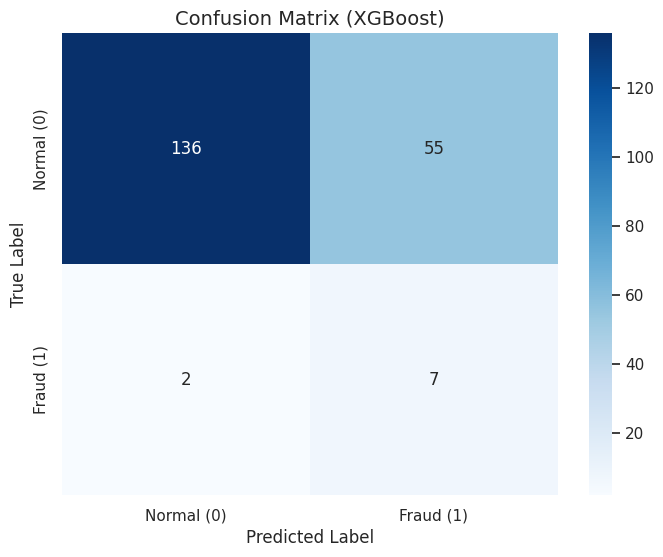

In [ ]:
# Plot Confusion Matrix with the NEW threshold
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Fraud (1)'],
            yticklabels=['Normal (0)', 'Fraud (1)'])

plt.title('Confusion Matrix (XGBoost)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

plt.show()

#***XGBoost ROC***


AUC Score: 0.7295


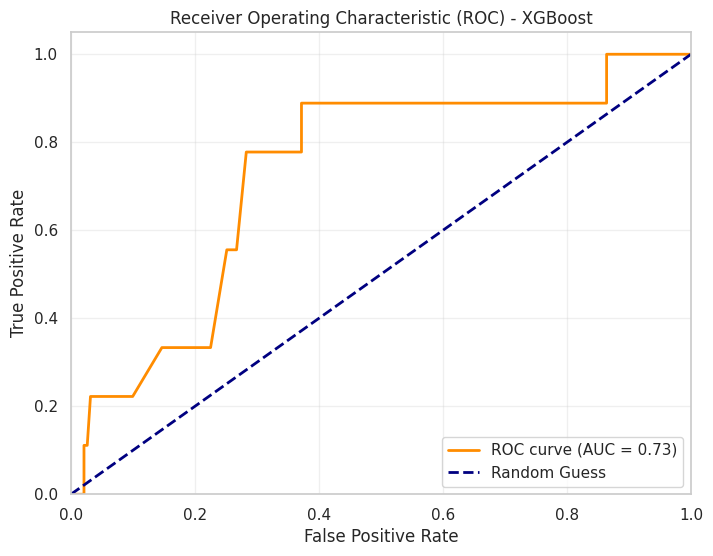

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC Curve metrics
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print(f"AUC Score: {auc_score:.4f}")

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - XGBoost')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

#***Top 10 Important Features***

<Figure size 1000x800 with 0 Axes>

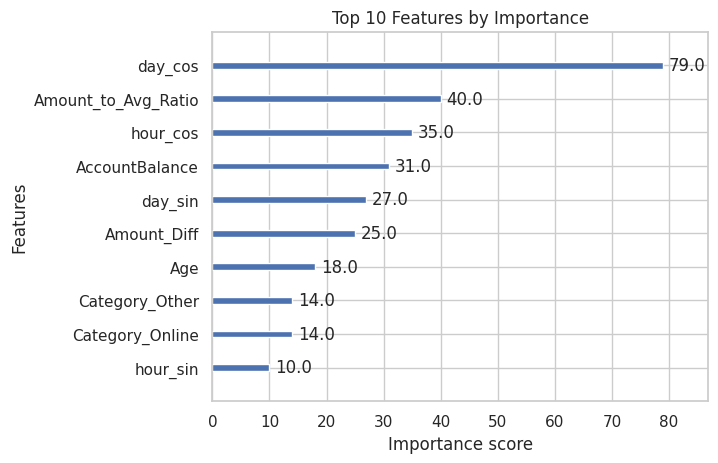

In [ ]:
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, max_num_features=10, importance_type='weight', title='Top 10 Features by Importance')
plt.show()

#***Champion Model***

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:27:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


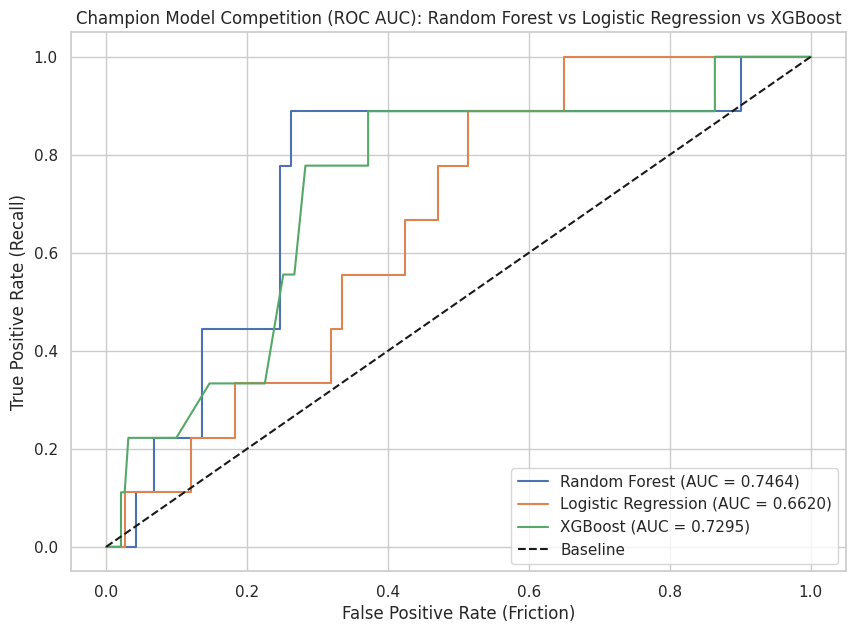

Results
Random Forest: ROC AUC = 0.7464
Logistic Regression: ROC AUC = 0.6620
XGBoost: ROC AUC = 0.7295
THE CHAMPION IS: Random Forest


In [ ]:
# 1. Initialize the ACTUAL contenders
models = {
    'Random Forest': RandomForestClassifier(n_estimators=500, max_depth=10, class_weight='balanced', random_state=42),
    'Logistic Regression': best_lr,
    'XGBoost': xgb.XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=2, use_label_encoder=False, eval_metric='logloss',random_state=0)
}

auc_results = {}
plt.figure(figsize=(10, 7))

# Execute a loop for each model
for name, model in models.items():
    # Fit on resampled training data
    model.fit(X_train_res, y_train_res)

    # Predict probabilities for the positive class (Fraud)
    y_probs = model.predict_proba(X_test)[:, 1]

    # Calculate ROC AUC
    auc = roc_auc_score(y_test, y_probs)
    auc_results[name] = auc

    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

# determine the Champion
champion_name = max(auc_results, key=auc_results.get)
champion_model = models[champion_name]

plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
plt.xlabel('False Positive Rate (Friction)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Champion Model Competition (ROC AUC): Random Forest vs Logistic Regression vs XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("Results")
for name, score in auc_results.items():
    print(f"{name}: ROC AUC = {score:.4f}")

print(f"THE CHAMPION IS: {champion_name}")

Generating SHAP explanation for: Random Forest...


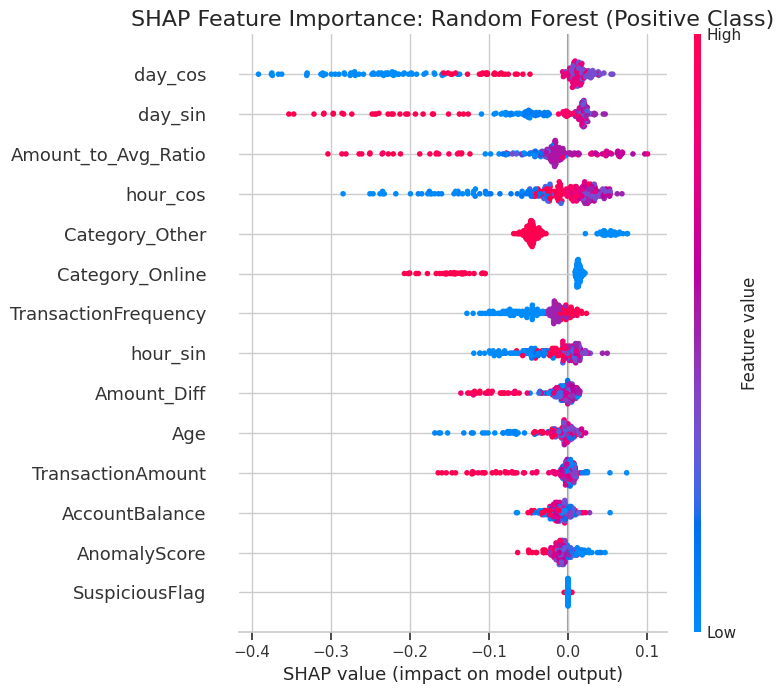

In [ ]:
# Use TreeExplainer
print(f"Generating SHAP explanation for: {champion_name}...")
explainer = shap.TreeExplainer(champion_model)

# Calculate SHAP Values
shap_values = explainer.shap_values(X_test, check_additivity=False)

# Handle Binary Classification Output
# If shap_values is a list (common for Random Forest), we select index 1 (The Positive Class)
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    # If it's a 3D array (samples, features, classes), slice the last dimension
    shap_values_to_plot = shap_values[:, :, 1]
else:
    shap_values_to_plot = shap_values

# Display the visualization
plt.figure(figsize=(10, 8))
plt.title(f"SHAP Feature Importance: {champion_name} (Positive Class)", fontsize=16)

shap.summary_plot(shap_values_to_plot, X_test, show=False)

plt.tight_layout()
plt.show()